<style>
/* Robust RTL for Persian notebook content */
.fa-rtl {
  direction: rtl !important;
  text-align: right !important;
}
.fa-rtl p, .fa-rtl h1, .fa-rtl h2, .fa-rtl h3, .fa-rtl h4, .fa-rtl h5, .fa-rtl h6,
.fa-rtl blockquote, .fa-rtl li {
  direction: rtl !important;
  text-align: right !important;
}
.fa-rtl ul, .fa-rtl ol {
  direction: rtl !important;
  text-align: right !important;
  padding-right: 2em !important;
  padding-left: 0 !important;
}
.fa-rtl pre, .fa-rtl pre code {
  direction: ltr !important;
  text-align: left !important;
  unicode-bidi: isolate !important;
}
.fa-rtl code {
  direction: ltr;
  unicode-bidi: isolate;
}
.fa-rtl .MathJax, .fa-rtl mjx-container {
  direction: ltr !important;
}
</style>

<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

# هفته ۱۱ — تمرین کلاسی: از Depth تا ResNet و استفاده دوباره از دانش یادگرفته‌شده

> **سؤال اصلی:** Depth باید یک شبکه را قدرتمندتر کند؛ پس چرا اضافه کردن layerهای بیشتر گاهی شبکه را *بدتر* می‌کند؟ و چطور یک ایده کوچک در architecture یعنی `shortcut connection` این مشکل را آن‌قدر خوب حل می‌کند که امروز می‌توانیم به‌جای train کردن یک شبکه از صفر، به‌صورت درست از یک شبکه از قبل train‌شده استفاده کنیم؟

## نمای کلی جلسه

- **مدت:** حدود ۳.۵ ساعت (این تمرین محتوای سه جلسه را یک‌جا جمع می‌کند: مسیر رسیدن به ResNet، Batch Normalization و pretrained feature extraction؛ بنابراین از یک تمرین معمولی طولانی‌تر است.)
- **Framework:** PyTorch و Torchvision
- **پروژه در حال اجرا:** دسته‌بندی چهار کلاس نزدیک به موضوع waste از CIFAR-10، در ادامه experiment log جلسه‌های ۱ تا ۴
- **مقاله‌ای که امروز واقعاً باید باز کنید:** He, Zhang, Ren, Sun, *"Deep Residual Learning for Image Recognition,"* CVPR 2016. نسخه arXiv (رایگان و با همان محتوا):
  [https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)
  (از لینک "HTML" یا "PDF" همان صفحه استفاده کنید؛ هر دو برای سؤال‌های امروز مناسب‌اند.) چند سؤال در Part 1، 2 و 4 شما را به یک **Figure، Table یا Equation شماره‌دار مشخص** در مقاله ارجاع می‌دهند. لازم نیست کل مقاله را بخوانید؛ فقط بخش‌هایی را که مشخص شده بررسی کنید.

## نقش‌های گروهی (در صورت تمایل هر یک ساعت جابه‌جا شوید)

- **Driver** — code را تایپ می‌کند و صفحه‌اش را share می‌کند.
- **Skeptic** — قبل از اینکه گروه به cell بعدی برود، باید مستقلاً shape/عددی را که گروه به آن رسیده دوباره محاسبه یا بررسی کند. اگر Skeptic نتواند با استدلال آن را بازتولید کند، کار گروه هنوز تمام نشده است.
- **Scribe** — پاسخ گروه به تمام سؤال‌های Markdown را با بیان خود گروه می‌نویسد، نه با copy/paste از صفحه یکی از اعضا.

## خروجی مورد انتظار گروه تا پایان تمرین

- [ ] همه cellهای code دارای `# TODO` کامل و قابل اجرا باشند.
- [ ] به همه سؤال‌های group discussion با بیان خودتان پاسخ داده شده باشد.
- [ ] بخش "Blueprint Audit" برای ResNet18 کامل شده باشد (Part 4).
- [ ] pipeline مربوط به feature extraction اصلاح شده و bugها پیدا و رفع شده باشند (Part 7).
- [ ] Experiment Log با اعداد Experiment C خودتان به‌روز شده باشد (Part 8).
- [ ] یک رأی در بخش Misconception Court ثبت شده باشد (Part 9).

از جایی که Session 3 تمام شد ادامه می‌دهیم.

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 0 — از کجا ادامه می‌دهیم؟ (حدود ۱۵ دقیقه)

## داستان تا اینجا

| Experiment | Model | Random augmentation | Initial weights | Trainable parameters |
|---|---|:---:|---|---|
| A | Small CNN | No | Random | All |
| B | Small CNN | Yes | Random | All |

Small CNN همراه با augmentation بهتر عمل کرد، اما در Session 3 یک محدودیت مطرح شد که augmentation به‌تنهایی نمی‌تواند آن را حل کند:

> Small CNN ما هنوز باید فقط با استفاده از یک dataset کوچک، featureهای بصری مفید را از صفر یاد بگیرد.

**بحث گروهی (۲ دقیقه، فعلاً چیزی ننویسید):** قبل از ادامه، هر نفر در گروه در یک جمله توضیح دهد چرا یک network *عمیق‌تر* ممکن است featureهای بهتری نسبت به Small CNN یاد بگیرد. سپس یک نفر توضیح دهد چرا Depth لزوماً به‌صورت خودکار کمک نمی‌کند. اگر گروه نتواند هم یک دلیل «موافق» و هم یک دلیل «مخالف» ارائه کند، هنوز برای رفتن به بخش بعد آماده نیستید.

**Q0.1:** حالا هر دو جمله را بنویسید: یک دلیل برای اینکه Depth می‌تواند کمک کند، و یک دلیل برای اینکه افزایش Depth لزوماً یک برد رایگان نیست.

> **پاسخ گروه:**
موافق: شبکه کانولوشنی با عمیق تر شدن و افزودن لایه ها ویژگی های بصری پیشرفته تری استخراج میکند برای مثال در لایه های اول ویژگی هایی مثل خطوط گوشه ها استخراج میشود و در لایههای اخری اشیا مفاهیم و بافت ها استخراج میشود

منفی: با افزایش لایه ها بهینه سازی سخت تر می شود . جریان گرادیان به درستی منتقل نمی شود.

</div>


In [35]:
# Setup — Driver گروه این cell را یک بار اجرا می‌کند و environment را با گروه به اشتراک می‌گذارد.
from copy import deepcopy
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
DATA_ROOT = Path("data")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {DEVICE}")

PyTorch version: 2.13.0+cpu
Using device: cpu


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## Dataset امروز

از همان proxy dataset مبتنی بر CIFAR-10 در Session 3 و 4 استفاده می‌کنیم، با این تفاوت که آن را به چهار class محدود کرده‌ایم تا هر گروه بتواند همه experimentهای امروز را بدون نیاز به GPU cluster اجرا کند. چون از Part 6 به بعد به input سازگار با ResNet18 نیاز داریم، از همان ابتدا همه تصاویر به `224 × 224` resize می‌شوند و وسط کار pipeline را عوض نمی‌کنیم.

</div>


In [36]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

deterministic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

raw_train_full = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=None)
raw_test_full = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=None)

project_classes = ["automobile", "ship", "truck", "airplane"]
project_class_ids = [raw_train_full.classes.index(c) for c in project_classes]
project_label_map = {orig: i for i, orig in enumerate(project_class_ids)}


def make_balanced_indices(targets, class_ids, n_per_class, seed=SEED):
    rng = random.Random(seed)
    targets = list(targets)
    chosen = []
    for c in class_ids:
        idx_c = [i for i, t in enumerate(targets) if t == c]
        rng.shuffle(idx_c)
        chosen.extend(idx_c[:n_per_class])
    rng.shuffle(chosen)
    return chosen


def make_val_test_split(targets, class_ids, n_val, n_test, seed=SEED):
    rng = random.Random(seed)
    targets = list(targets)
    val_indices, test_indices = [], []
    for c in class_ids:
        idx_c = [i for i, t in enumerate(targets) if t == c]
        rng.shuffle(idx_c)
        val_indices.extend(idx_c[:n_val])
        test_indices.extend(idx_c[n_val:n_val + n_test])
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)
    return val_indices, test_indices


class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform, label_map=None):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        if self.label_map is not None:
            label = self.label_map[label]
        return self.transform(image), label


train_indices = make_balanced_indices(raw_train_full.targets, project_class_ids, n_per_class=40, seed=SEED)
val_indices, test_indices = make_val_test_split(raw_test_full.targets, project_class_ids, n_val=20, n_test=20, seed=SEED)

train_dataset = TransformSubset(raw_train_full, train_indices, deterministic_transform, label_map=project_label_map)
val_dataset = TransformSubset(raw_test_full, val_indices, deterministic_transform, label_map=project_label_map)
test_dataset = TransformSubset(raw_test_full, test_indices, deterministic_transform, label_map=project_label_map)

class_names = project_classes
print("Classes:", class_names)
print("Train images:", len(train_dataset), "| Val images:", len(val_dataset), "| Test images:", len(test_dataset))

Classes: ['automobile', 'ship', 'truck', 'airplane']
Train images: 160 | Val images: 80 | Test images: 80


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 1 — معمای `degradation`: پرونده شماره 34 (حدود ۳۰ دقیقه)

گروه شما با یک پرونده عجیب از سال ۲۰۱۵ روبه‌رو شده است. یک تیم در Microsoft Research دو network از نوع "plain" (یعنی stackهایی از convolution بدون shortcut) را روی ImageNet train کرد: یکی ۱۸ layer و دیگری ۳۴ layer. به‌طور شهودی انتظار داریم network با ۳۴ layer — که capacity بیشتری دارد و فضای solution شبکه ۱۸-layer عملاً زیرمجموعه‌ای از چیزهایی است که شبکه ۳۴-layer می‌تواند represent کند — حداقل به همان خوبی عمل کند.

اما این‌طور نشد.

## مدرک A — خودتان بررسی کنید

مقاله را باز کنید (لینک در مقدمه) و **Table 2** با عنوان "Top-1 error (%, 10-crop testing) on ImageNet validation" را پیدا کنید. چهار عدد در آن وجود دارد: plain-18، plain-34، ResNet-18 و ResNet-34.

**Q1.1 (ثبت شواهد):** هر چهار عدد Table 2 را یادداشت کنید.
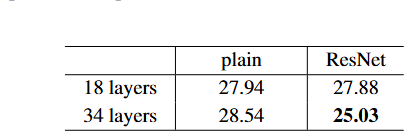

> **پاسخ گروه:**

**Q1.2 (معما):** مقدار `plain-34 error − plain-18 error` را حساب کنید. علامت نتیجه مثبت است یا منفی؟ این علامت به زبان ساده چه معنایی دارد؛ network عمیق‌ترِ *plain* نسبت به نسخه کم‌عمق‌تر بهتر عمل کرده یا بدتر؟

> **پاسخ گروه:**
مقدار مثبت است یعنی خطا افزایش یافته و به این معناست که مدل عمیق تر پلین بدتر بوده است.

**Q1.3 (نکته غیرمنتظره):** حالا `ResNet-34 error − ResNet-18 error` را حساب کنید و علامت آن را با Q1.2 مقایسه کنید. واضح است که بین زوج plain networkها و زوج ResNetها چیزی تغییر کرده است. در یک جمله بگویید چه چیزی بین این دو زوج network تغییر کرده است (راهنمایی: *تعداد layerها نیست*).

> **پاسخ گروه:**
تو شبکع رزنت به خاطر وجود اسکیپ جریان گرادیان حفظ شده است در نتیجه خروجی منقی است

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## مدرک B — مظنون بدیهی را کنار بگذارید

ممکن است اولین حدس شما این باشد که «plain network با ۳۴ layer دچار overfitting شده است». قبل از اینکه گروه این فرضیه را بپذیرد، **Figure 4** مقاله با عنوان "Training on ImageNet" را پیدا کنید. caption آن را با دقت بخوانید؛ دقیقاً مشخص می‌کند curveهای نازک و curveهای ضخیم چه چیزی را نشان می‌دهند.

**Q1.4:** طبق caption شکل Figure 4، curveهای **نازک** چه چیزی را نشان می‌دهند و curveهای **ضخیم** چه چیزی را؟

> **پاسخ گروه:**
ضخیم: ولیدیشن
نازک: ترین

**Q1.5 (مدرکی که overfitting را رد می‌کند):** به پنل **سمت چپ** Figure 4 (plain networkها) نگاه کنید. اگر plain network با ۳۴ layer فقط دچار overfitting شده بود، انتظار داشتیم curve مربوط به *training* آن بهتر باشد (یعنی training error پایین‌تری نسبت به network با ۱۸ layer داشته باشد)، حتی اگر curve مربوط به *validation* بدتر باشد. آیا چیزی که در پنل چپ می‌بینید با این انتظار سازگار است؟ در پاسخ حتماً از عبارت مشخص `training error` استفاده کنید، نه فقط کلمه کلی «performance».

> **پاسخ گروه:**
با توجه به این که ترین و ولیدیشن ارور بالایی داشتند و ارور ترین کمتر از ارور ولیدیشن نبود و این اتفاق در اثر بالا رفتن عمق شبکه ایجاد شد degradation پرابلم بود.

**Q1.6:** با توجه به پاسخ Q1.5، چرا تشخیص «network با ۳۴ layer دچار overfitting شده» اشتباه است؟ نام درست این مشکل چیست و چطور می‌توانید آن را در یک جمله، بدون استفاده از واژه `overfitting`، تعریف کنید؟

> **پاسخ گروه:**
degradation problem زمانی رخ میدهد که با بالارفتن عمق و پیچیدگی شبکه جریان گرادیان محو شود و منجر به سقوط دقت train و دقت test  به طور همزمان شود
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## بازسازی صحنه (مثال آموزشی، نه اعداد واقعی)

در Session 3 یک نمونه ساده‌شده از این الگو دیدید:

| Model | Training accuracy | Validation accuracy |
|---|---:|---:|
| 20-layer plain network | 92% | 87% |
| 56-layer plain network | 85% | 81% |

**TODO:** به‌صورت گروهی یک function پایتون با نام `is_degradation(shallow_train_acc, shallow_val_acc, deep_train_acc, deep_val_acc)` بنویسید که فقط زمانی `True` برگرداند که الگو واقعاً `degradation` باشد؛ یعنی model عمیق‌تر **در training accuracy هم** بدتر باشد، نه فقط در validation. برای یک الگوی معمولی `overfitting` باید `False` برگرداند؛ یعنی training accuracy مدل عمیق‌تر از مدل کم‌عمق‌تر *بیشتر* باشد ولی validation accuracy آن کمتر باشد. function را هم روی جدول بالا و هم روی یک مثال ساختگی از `overfitting` که خود گروه می‌سازد، تست کنید.

</div>


In [37]:
def is_degradation(shallow_train_acc, shallow_val_acc, deep_train_acc, deep_val_acc):
    # TODO: اگر training accuracy مدل عمیق‌تر از مدل کم‌عمق‌تر کمتر است، True برگردانید
    # (این الگوی مشخصه degradation است). در غیر این صورت False برگردانید.
    status = None
    if deep_train_acc - shallow_train_acc < 0 :
        status = 'degradation'
    else:
        status = "overfitting"
    return status
# جدول نمونه از Session 3:
print("Session 3 table:", is_degradation(0.92, 0.87, 0.85, 0.81))
print("overfitting example:", is_degradation(0.92, 0.87, 1, 0.71))

# TODO: برای یک مدل کم‌عمق و یک مدل عمیق، زوج‌های ساختگی (train_acc, val_acc) بسازید
# که به‌جای degradation یک ORDINARY OVERFITTING را نشان دهند، سپس بررسی کنید
# function شما برای این مثال به‌درستی False برمی‌گرداند.
# print("مثال overfitting گروه:", is_degradation(..., ..., ..., ...))

Session 3 table: degradation
overfitting example: overfitting


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## مدرک C — thought experiment پشت راه‌حل

در **Section 1 (Introduction)** مقاله — یا مرور مشابه آن در Session 3 — پاراگراف مربوط به "identity mapping thought experiment" را پیدا کنید: اگر یک network کم‌عمق از قبل چیز مفیدی محاسبه می‌کند، نسخه عمیق‌تر *باید* بتواند حداقل همان عملکرد را با یاد گرفتن identity function در layerهای اضافه حفظ کند.

**Q1.7:** با بیان خودتان توضیح دهید چرا این thought experiment نشان می‌دهد پیدا کردن یک solution مناسب برای layerهای plain (غیر residual) از نظر optimization سخت‌تر از چیزی است که در نگاه اول به نظر می‌رسد؛ با اینکه از نظر تئوری، «هیچ کاری نکردن» یک solution معتبر است که layerهای اضافه می‌توانند represent کنند.

> **پاسخ گروه:**
> در شبکه های پلین identity  یک solution بسیار سخت است که اپتیمایزر به راحتی نمی تواند آن را بهینه کند
> در حالی که در شبکه های Residual ماتریس identity  بخشی از معماری شبکه است و نیازی به اپتیمایزر برای کشف شدن ندارد

**Q1.8 (پل به سمت راه‌حل):** این جمله را به‌صورت گروهی کامل کنید، بدون استفاده از کلمه «بهتر»: *اگر یاد گرفتن یک identity mapping دقیق از میان چند nonlinear layer پشت سر هم سخت باشد، یک راه این است که چیزی را که layerها باید یاد بگیرند از «بازسازی input» به «___________» تغییر دهیم.*

> **پاسخ گروه:**
یک اسکیپ کانکشن
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 2 — Residual Learning: از Equation تا Code (حدود ۳۵ دقیقه)

## راه‌حل را مستقیماً از منبع بخوانید

مقاله را باز کنید و **Section 3.2, "Identity Mapping by Shortcuts"** را پیدا کنید. building block اصلی در **Equation (1)** آمده است.

**Q2.1:** Equation (1) را دقیقاً همان‌طور که نوشته شده کپی کنید (با استفاده از `F`، `x` و `y`؛ برای زیرنویس weight می‌توانید `Wi` بنویسید). سپس با بیان خودتان نقش هر یک از این سه نماد را مشخص کنید: `x` چیست، `F(x, {Wi})` چیست و `y` چیست؟

> **پاسخ گروه:**
>
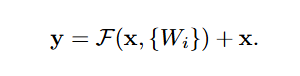
> <br>
> F = residual layer<br>
> Wi = weight matrix<br>
> x = skip connection<br>
همان section توضیح می‌دهد وقتی shapeهای `x` و `F(x)` با هم برابر نیستند، مقاله به‌جای آن از **Equation (2)** با matrix به نام `Ws` استفاده می‌کند.

**Q2.2:** Equation (2) را کپی کنید. در code مربوط به PyTorch که در Session 3 دیده‌اید، کدام operation نقش `Ws` را بازی می‌کند؟

> **پاسخ گروه:**<br>
> 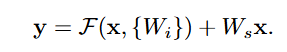<br>
```Code
        > if shape_changes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
            >
```

operation shortcut<br>
**Q2.3 (یک نکته ظریف):** در Section 3.2 گفته شده shortcut connectionهای Equation (1) «نه parameter اضافه می‌کنند و نه computation complexity». آیا همین ادعا برای Equation (2) هم درست است؟ پاسخ خود را بر اساس اینکه `Ws` واقعاً چیست توضیح دهید.

> **پاسخ گروه:**
بله به علت کرنل و بچ نرمالایز استفاده شده در اسکیپ کانکشن هم بار محاسباتی اضافه شده هم پیچیدگی شبکه افزایش یافته
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## Correction، نه reconstruction

در Session 3 از یک تشبیه ویرایشی استفاده شد: یک plain block کل سند را دوباره می‌نویسد؛ یک residual block نسخه فعلی را نگه می‌دارد و فقط تغییرات لازم را یاد می‌گیرد. به‌صورت رسمی:

$$
y = x + F(x), \qquad \text{so if } F(x) \approx 0 \text{, then } y \approx x
$$

**Q2.4 (لحظه whiteboard گروهی — چیزی را که می‌کشیدید توضیح دهید):** فرض کنید الآن whiteboard در اختیار دارید. diagram دو-مسیره یک residual block را با کلمات توصیف کنید: در "learned branch" چه اتفاقی می‌افتد، در "shortcut branch" چه اتفاقی می‌افتد و این دو مسیر کجا به هم می‌رسند. همان ساختار دو-مسیره **Figure 2** مقاله را استفاده کنید (الآن آن را باز کنید و sketch خود را با آن مقایسه کنید) و operationهای learned branch را به ترتیب نام ببرید.

> **پاسخ گروه:**<br>
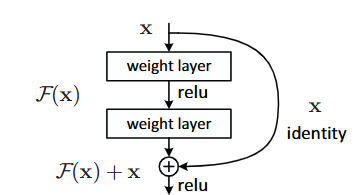

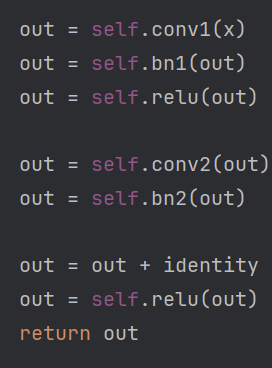
<p dir=ltr>

</div>

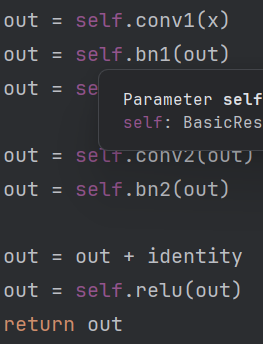

<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## حالا آن را پیاده‌سازی کنید

**TODO:** متد `BasicResidualBlock.forward()` در پایین را کامل کنید. بخش `__init__` از قبل نوشته شده و `conv1`، `bn1`، `relu`، `conv2`، `bn2` و `self.shortcut` را مطابق همان ساختار دو-مسیره‌ای که توضیح دادید می‌سازد. وظیفه شما فقط پیاده‌سازی متد `forward` است؛ از block diagram نوشته‌شده در comment بالای آن پیروی کنید.

</div>


In [38]:
class BasicResidualBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        shape_changes = stride != 1 or in_channels != out_channels
        if shape_changes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        # Learned path:  x -> conv1 -> bn1 -> relu -> conv2 -> bn2  -> (نام آن را `out` بگذارید)
        # Shortcut path: x -> self.shortcut(x)                      -> (نام آن را `identity` بگذارید)
        # Combine:       out = out + identity، سپس self.relu را یک بار دیگر اعمال کنید)
        shortcut = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + shortcut
        out= self.relu(out)

        return out



<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## نتیجه را برای Skeptic ثابت کنید

**TODO:** هر دو block پایین را اجرا کنید. قبل از اجرا، گروه باید فقط با استفاده از argumentهای constructor، **دو output shape را روی کاغذ پیش‌بینی کند**. سپس cell را اجرا کنید و Skeptic بررسی کند که prediction با خروجی واقعی یکسان است.

</div>


In [39]:
x = torch.randn(4, 64, 56, 56)

identity_block = BasicResidualBlock(in_channels=64, out_channels=64, stride=1)
y_identity = identity_block(x)

projection_block = BasicResidualBlock(in_channels=64, out_channels=128, stride=2)
y_projection = projection_block(x)

print("Identity block   -> input:", tuple(x.shape), " output:", tuple(y_identity.shape))
print("Identity shortcut type:  ", identity_block.shortcut)
print()
print("Projection block -> input:", tuple(x.shape), " output:", tuple(y_projection.shape))
print("Projection shortcut type:", projection_block.shortcut)

Identity block   -> input: (4, 64, 56, 56)  output: (4, 64, 56, 56)
Identity shortcut type:   Identity()

Projection block -> input: (4, 64, 56, 56)  output: (4, 128, 28, 28)
Projection shortcut type: Sequential(
  (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
  (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q2.5:** گروه شما این shapeها را *قبل از اجرای cell* پیش‌بینی کرده است. آیا هر دو prediction درست بودند؟ اگر prediction یکی از اعضای گروه اشتباه بود، دقیقاً مشخص کنید کدام عدد (batch، channels، height یا width) اشتباه شده و دلیل آن چه بوده است.

> **پاسخ گروه:**
بله پیش بینی با خروجی سلول تطابق داشت
>
**Q2.6 (بررسی با مقاله):** **Figure 3** مقاله را پیدا کنید. سه architecture کنار هم نشان داده شده‌اند: VGG-19، یک plain network با ۳۴ layer و یک residual network با ۳۴ layer. در diagram سمت راست، به shortcut lineهای **نقطه‌چین** و **پیوسته** نگاه کنید. کدام‌یک از دو block تست‌شده (`identity_block` یا `projection_block`) معادل shortcut **نقطه‌چین** در Figure 3 است و کدام معادل shortcut **پیوسته**؟ پاسخ را با استفاده از caption یا متن اطراف Section 3.3 با عنوان "Network Architectures" توجیه کنید.

> **پاسخ گروه:**
>
> 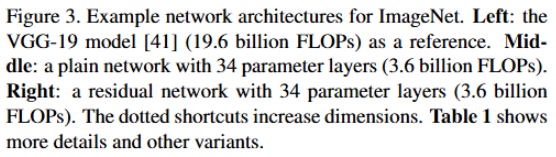
>
> اتصال های باقی مانده به صورت نقطه چین نماینده پراجکشن یا تغییر ابعاد هستند

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 3 — توقف کوتاه برای BatchNorm (حدود ۱۵ دقیقه)

دقت کنید که در `BasicResidualBlock` بلافاصله بعد از هر `conv` یک `BatchNorm2d` قرار گرفته و هر `conv` نیز `bias=False` دارد. این فقط یک انتخاب ظاهری در style code نیست؛ قبل از ساختن ResNet18 کامل در Part 4 ارزش دارد ۱۵ دقیقه برای فهمیدن دلیل آن وقت بگذاریم.

**Q3.1 (چرا bias نداریم؟):** فرمول BatchNorm برابر `y = γ·x̂ + β` است که در آن `β` یک shift یادگرفتنی برای هر channel است. یک `nn.Conv2d` معمولی، اگر `bias=False` نداشته باشد، bias یادگرفتنی خودش را *قبل از* اینکه BatchNorm میانگین batch را کم کند اضافه می‌کند. وقتی bias مربوط به convolution وارد مرحله mean-subtraction در BatchNorm بعدی می‌شود، چه اتفاقی برای آن می‌افتد؟ (راهنمایی: فکر کنید `mean(x + constant)` چه می‌شود و BatchNorm با آن mean چه می‌کند.)

> **پاسخ گروه:**
بچ نرمالایز ، بایاس تولید شده توسط لایه کانولوشنی رو از بین میبره و بتا خود بچ نرمالایز جایگزین میشه پس فعال کردن بایاس برای آن لایه صرفا هدر رفت منابع هست
>
**Q3.2 (train در برابر eval، به‌صورت مشخص):** فرض کنید گروه یک model train‌شده را روی **یک test image** با batch size برابر ۱ ارزیابی می‌کند و فراموش می‌کند ابتدا `model.eval()` را صدا بزند. BatchNorm در این حالت تلاش می‌کند batch mean و variance را از دقیقاً چند مقدار در هر channel محاسبه کند؟ چرا این موضوع برای داشتن یک prediction پایدار و تکرارپذیر مشکل‌ساز است؟

> **پاسخ گروه:**
با فعال نکردن حالت ارزیابی در مدل باعث میشویم که مدل پارامتر های بچ نرمالایز رو به روز رسانی کنه و ناخواسته پارامتر های یادگیری شده رو آلوده کنیم

همچنین باعث میشیم نرمالیزیشنی که روی تصویر اعمال میشه نویزی و ناپایدار و وابسته به بچ تصادفی باشه که این عمل باعث میشه هر بار یک فرایند متفاوت برای تصویر اتفاق بیوفته
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## فقط قبول نکنید؛ خودتان بررسی کنید

**TODO:** یک layer از نوع `nn.BatchNorm2d(3)` بسازید. همان batch از داده random را دو بار به آن بدهید: یک بار در حالت `.train()` و یک بار در حالت `.eval()` (حتماً هر دو بار همان input را استفاده کنید). دو output و مقدار `running_mean` قبل و بعد از هر call را مقایسه کنید.

</div>


In [40]:
torch.manual_seed(0)
probe_layer = nn.BatchNorm2d(3)
probe_batch = torch.randn(8, 3, 4, 4) * 5 + 2  # deliberately not mean-0, std-1

print("running_mean BEFORE any forward pass:", probe_layer.running_mean)

# TODO: probe_layer را در EVAL mode قرار دهید، همان probe_batch را دوباره از آن عبور دهید،
#       و statistics خروجی (مثلاً output.mean() و output.std()) را در مقایسه با
#       statistics مربوط به train-mode چاپ کنید.
probe_layer.eval()
output_eval_mode = probe_layer(probe_batch)
print("running_mean after eval mode forward pass:", probe_layer.running_mean)

# TODO: probe_layer را در TRAIN mode قرار دهید، probe_batch را یک بار از آن عبور دهید،
#       و running_mean را بعد از این call چاپ کنید.
probe_layer.train()
output_train_mode = probe_layer(probe_batch)
print("running_mean after train mode forward pass:", probe_layer.running_mean)
probe_layer.train()
output_train_mode = probe_layer(probe_batch)
output_train_mode = probe_layer(probe_batch)
output_train_mode = probe_layer(probe_batch)
print("running_mean after train mode and 3 call forward pass:", probe_layer.running_mean)
# سؤال‌های راهنما که حین کار با print() بررسی می‌کنید:
# - آیا running_mean بعد از عبور در train-mode تغییر کرد؟
# - آیا برای دقیقاً همان input، خروجی train-mode و eval-mode از نظر عددی یکسان‌اند؟
#   چرا یا چرا نه؟

running_mean BEFORE any forward pass: tensor([0., 0., 0.])
running_mean after eval mode forward pass: tensor([0., 0., 0.])
running_mean after train mode forward pass: tensor([0.2206, 0.2423, 0.1998])
running_mean after train mode and 3 call forward pass: tensor([0.7587, 0.8332, 0.6870])


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q3.3:** بر اساس چیزی که مشاهده کردید، جدول زیر را با **بیان خودتان** کامل کنید (از متن notebook copy/paste نکنید):

| سؤال | Training mode         | Eval mode              |
|---|-----------------------|------------------------|
| BatchNorm از کدام mean/variance استفاده می‌کند؟ | آمار مربوط به بچ فعلی | آمار از قبل آموخته شده |
| آیا `running_mean` به‌روزرسانی می‌شود؟ | بله                   | خیر                    |
| آیا output برای یک input ثابت در callهای تکراری همیشه دقیقاً یکسان است؟ | خیر                   | بله                    |

> **پاسخ گروه (جدول بالا را کامل کنید):**

**Q3.4 (ارتباط با Part 7 که جلوتر می‌آید):** در recipe مربوط به feature extraction در Session 4، backbone مربوط به ResNet با تنظیم `requires_grad=False` برای parameterها freeze می‌شود و جداگانه قبل از `model.fc.train()`، روی کل model دستور `model.eval()` اجرا می‌شود. بر اساس مطالب همین Part، در یک جمله توضیح دهید چرا `requires_grad=False` **به‌تنهایی** کافی نیست تا تضمین کند backbone هنگام training کاملاً frozen باقی می‌ماند؛ چه چیزی هنوز ممکن است بدون اینکه متوجه شوید تغییر کند؟

> **پاسخ گروه:**
آمار های پیش آموزش دیده مثل آزمایش سلول قبلی در حالت ترین تغییر میکند ! حتی اگر پارامتر های قابل یادگیری مدل عوض نشود میانگین و واریانس استخراج شده توسط بچ نرمالایز عوض میشود و باعث تغییرات ناخواسته در رفتار مدل و خروجی ویژگی ها میشود
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 4 — ساخت ResNet18: Blueprint Audit (حدود ۲۵ دقیقه)

حالا گروه شما نقش تیم quality assurance را دارد. Torchvision ادعا می‌کند implementation مربوط به `resnet18` با architecture مقاله یکسان است. وظیفه شما این است که این ادعا را با **Table 1** مقاله ("Architectures for ImageNet") بررسی کنید.

## Blueprint را load کنید

**TODO:** `resnet18` را با weightهای **random** load کنید (در این بخش architecture را audit می‌کنیم، نه دانش pretrained؛ آن موضوع مربوط به Part 6 است) و head آن را برای پروژه ۴-class خودمان، دقیقاً مشابه Session 3، جایگزین کنید.

</div>


In [41]:
NUM_CLASSES = len(class_names)

model = resnet18(weights=None)
original_features = model.fc.in_features
model.fc = nn.Linear(original_features, NUM_CLASSES)
model = model.to(DEVICE)

print("Residual blocks per stage:", [len(model.layer1), len(model.layer2), len(model.layer3), len(model.layer4)])

Residual blocks per stage: [2, 2, 2, 2]


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## Table 1 را دقیق بررسی کنید

مقاله را باز کنید و **Table 1** را پیدا کنید. ستون "18-layer" را پیدا کنید.

**Q4.1:** در Table 1، configuration مربوط به هر stage از `conv2_x` تا `conv5_x` به شکلی مثل `[3×3, 64] × 2` نوشته شده است. `× 2` از نظر تعداد blockهای `layer1`/`layer2`/`layer3`/`layer4` که بالاتر print کردید چه معنایی دارد؟ بررسی کنید list چهارعددی printشده شما با ستون 18-layer در Table 1 مطابقت دارد.

> **پاسخ گروه:**
بله ، هر استیج نماینده 2 بیسیک بلاک هست و در مجموع 4 استیج 2 تایی داریم که هر بیسیک بلاک 2 لایه کانولوشنی رزیجوآل رو شامل میشود پس معماری با تیبل مقاله تطبیق دارد

**Q4.2 (معمای تعداد layerها):** در Session 3 نام ResNet18 با شمارش زیر توضیح داده شد:

```text
1 (stem conv) + (8 blocks × 2 convs each) + 1 (fc) = 18
```

حالا ستون **34-layer** در Table 1 را پیدا کنید. با همان روش شمارش، محاسبه‌ای بنویسید که به 34 می‌رسد. سپس ستون **50-layer** را ببینید. اگر *دقیقاً همان formula* یعنی stem + blocks×2 + fc را با block countهای این ستون استفاده کنید، آیا نتیجه 50 می‌شود؟ اگر نه، توضیح دهید blockهای 50-layer چه تفاوتی دارند که این formula ساده دیگر جواب نمی‌دهد. (راهنمایی: توضیح/header مربوط به block در ستون 50-layer در Table 1 و جدول "A small family comparison" در Session 3 را دوباره بخوانید.)

> **پاسخ گروه:**

خیر تعداد بلاک های هر استیج متفاوت است ، همچنین هر بلاک به جای 2 لایه 3 لایه رزیجوآل دارد
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## قبل از اینکه کامپیوتر انجام دهد، همه shapeها را دستی trace کنید

**Q4.3 (اول prediction):** فقط با استفاده از stage table در Session 3 (stem → layer1 → layer2 → layer3 → layer4 → avgpool → fc) و قانون «stageهای با stride-2، height و width را نصف و channelها را دو برابر می‌کنند»، output shape بعد از **layer3** را برای batch شامل ۲ تصویر با اندازه `[2, 3, 224, 224]` پیش‌بینی کنید. محاسبات گروه را مرحله‌به‌مرحله بنویسید و فقط final answer را ننویسید.

> **پاسخ گروه (محاسبات را نشان دهید):**
``` Math
2 × 3 × 224 × 224

2 × 64 × 112 × 112

2 × 64 × 56 × 56

2 × 128 × 28 × 28

2 × 256 × 14 × 14
2 × 512 × 7 × 7

Ave pool => 2 × 512 × 1 × 1

Flatten => 2 × 512

FC =>  2 × 4
```
**TODO:** حالا function مربوط به shape tracing را بنویسید و prediction گروه را بررسی کنید.

</div>


In [42]:
@torch.inference_mode()
def trace_resnet_shapes(model, batch):
    model.eval()
    shapes = [("input", tuple(batch.shape))]

    # TODO: `batch` را به‌ترتیب از model.conv1، model.bn1 و model.relu عبور دهید
    #       و ("stem", shape) را به `shapes` اضافه کنید
    out = model.conv1(batch)
    shapes.append(("Stem", tuple(out.shape)))
    out = model.bn1(out)
    shapes.append(("bn1", tuple(out.shape)))
    out = model.relu(out)
    shapes.append(("relu", tuple(out.shape)))
    # TODO: نتیجه را از model.maxpool عبور دهید و ("maxpool", shape) را اضافه کنید
    out = model.maxpool(out)
    shapes.append(("maxpool", tuple(out.shape)))
    # TODO: به‌ترتیب از model.layer1، model.layer2، model.layer3 و model.layer4 عبور دهید
    #       و shape هرکدام را با label مربوط به خودش به `shapes` اضافه کنید
    out = model.layer1(out)
    shapes.append(("layer1", tuple(out.shape)))
    out = model.layer2(out)
    shapes.append(("layer2", tuple(out.shape)))
    out = model.layer3(out)
    shapes.append(("layer3", tuple(out.shape)))
    out = model.layer4(out)
    shapes.append(("layer4", tuple(out.shape)))
    # TODO: از model.avgpool عبور دهید و ("avgpool", shape) را اضافه کنید
    out = model.avgpool(out)
    shapes.append(("avgpool", tuple(out.shape)))
    # TODO: torch.flatten(x, 1) را اجرا کنید و ("flatten", shape) را اضافه کنید
    out = torch.flatten(out,1)
    shapes.append(("flatten", tuple(out.shape)))

    # TODO: از model.fc عبور دهید و ("logits", shape) را اضافه کنید
    out = model.fc(out)
    shapes.append(("fc", tuple(out.shape)))
    return shapes


dummy_images = torch.randn(2, 3, 224, 224, device=DEVICE)
for stage_name, shape in trace_resnet_shapes(model, dummy_images):
    print(f"{stage_name:8s} -> {shape}")

input    -> (2, 3, 224, 224)
Stem     -> (2, 64, 112, 112)
bn1      -> (2, 64, 112, 112)
relu     -> (2, 64, 112, 112)
maxpool  -> (2, 64, 56, 56)
layer1   -> (2, 64, 56, 56)
layer2   -> (2, 128, 28, 28)
layer3   -> (2, 256, 14, 14)
layer4   -> (2, 512, 7, 7)
avgpool  -> (2, 512, 1, 1)
flatten  -> (2, 512)
fc       -> (2, 4)


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q4.4:** آیا shape چاپ‌شده بعد از `layer3` با prediction شما در Q4.3 یکسان بود؟ اگر نه، دقیقاً پیدا کنید محاسبات شما از کدام مرحله با output واقعی متفاوت شده است.

> **پاسخ گروه:**

تمام مراحل با محاسبه دستی تطبیق داشت

**Q4.5 (مورد متفاوت):** تقریباً همه stageها از `layer1` تا `layer4` از الگوی «resolution نصف می‌شود و channels دو برابر می‌شوند» پیروی می‌کنند، اما یک transition متفاوت است. در shape trace کامل خودتان نگاه کنید: کدام transition مقدار **channel count** را از `3 → 64` تغییر می‌دهد بدون اینکه صرفاً channelهای stage قبلی را دو برابر کند، و کدام layer مسئول آن است؟ چرا این transition اول با الگوی `layer1 → layer2 → layer3 → layer4` متفاوت است؟

> **پاسخ گروه:**
Stem اولین لایه است و تصویر خام را برای ورود به شبکه آماده میکند
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 5 — Shape Detective 2.0 (حدود ۱۵ دقیقه)

در گروه ۳ نفره، برای هر case دو نفر مستقل ۶۰ ثانیه روی پاسخ کار کنند و بعد جواب‌ها را مقایسه کنید؛ اگر اختلاف داشتید، قبل از نوشتن پاسخ نهایی گروه درباره آن بحث کنید. (با ۳ نفر، در هر case نفری که مستقیماً حل نمی‌کند را جابه‌جا کنید.)

برای هر case فرض کنید اولین convolution با اندازه `3 × 3` در learned branch از stride مشخص‌شده استفاده می‌کند و تعداد output channel آن نیز همان مقداری است که در جدول آمده؛ دقیقاً مشابه `conv1` در `BasicResidualBlock`.

| Case | Input shape | Output channels | Stride | Identity (Eq. 1) or projection (Eq. 2)? | Output shape         |
|---|---|---:|---:|-----------------------------------------|----------------------|
| F | `[B, 32, 112, 112]` | 32 | 1 | identity                                | `[B, 32, 112, 112]`  |
| G | `[B, 32, 112, 112]` | 32 | 2 | projection                              | `[B, 32, 56, 56]`    |
| H | `[B, 512, 7, 7]` | 512 | 1 | identity                                | `[B, 512, 7, 7]`     |
| I | `[B, 256, 14, 14]` | 512 | 1 | projection                              | `[B, 512, 14, 14]`   |
| J | `[B, 64, 224, 224]` | 128 | 2 | projection                              | `[B, 128, 112, 112]` |

**Q5.1:** جدول بالا را کامل کنید.

> **پاسخ گروه:**

**Q5.2 (case تله):** یکی از پنج case بالا عمداً غیرمعمول است: channel count تغییر نمی‌کند، اما shape همچنان اجازه استفاده از یک identity shortcut خالص را نمی‌دهد. کدام case است؟ چرا فقط تغییر stride، حتی وقتی channel count ثابت مانده، شما را مجبور می‌کند از Equation (2) استفاده کنید؟

> **پاسخ گروه:**
> چون نمی تونیم دو تا تنسور با ابعاد نا هماهنگ رو بدون پروجکشن جمع کنیم

**Q5.3 — بدون استفاده از دو کلمه ممنوعه توضیح دهید.** جمله زیر را به‌صورت گروهی کامل کنید. در پاسخ **نباید** از کلمه‌های «بهتر» یا «پیشرفته‌تر» استفاده کنید:

> یک residual connection باعث می‌شود optimization یک deep block آسان‌تر شود، چون…

در پاسخ به shortcut، مسیر identity-like و یاد گرفتن یک correction اشاره کنید، اما *mechanism* را توضیح دهید و صرفاً vocabulary را تکرار نکنید.

> **پاسخ گروه:**
چون با ایدنتیتی کانکشن گرادیان های لایه های قبلی رو انتقال میده و در صورتی که خروجی یک لایه به صفر میل کنه ایدنتیتی کانکشن جریان گرادیان رو حفظ میکنه
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 6 — آشنایی با Pretrained Model (حدود ۲۰ دقیقه)

تا اینجا همه‌چیز با `resnet18(weights=None)` انجام شد؛ blueprint درست بود اما هیچ دانش قبلی داخل آن نبود. حالا فقط یک argument را تغییر می‌دهیم.

## دو نیروی جدید

این تشبیه را به یاد بیاورید: فرض کنید دو نیروی جدید وارد یک مرکز بازیافت شده‌اند.

- **Employee A** هیچ تجربه‌ای در کار با تصویر ندارد و باید vision را از ابتدا یاد بگیرد.
- **Employee B** سال‌ها اشیای روزمره را تشخیص داده، اما هنوز چهار waste label این مرکز را نمی‌شناسد.

**Q6.1 (بحث گروهی):** `resnet18(weights=None)` کدام employee است؟ `resnet18(weights=ResNet18_Weights.DEFAULT)` کدام employee است؟ کدام‌یک باید «چطور دیدن» را یاد بگیرد و کدام‌یک بیشتر لازم است یاد بگیرد «اینجا چیزها را چه نامی می‌گذاریم»؟

> **پاسخ گروه:**

## آن را load کنید و یک سؤال از آن بپرسید

**TODO:** pretrained weights را load کنید و metadata همراه آن‌ها را بررسی کنید.

</div>


In [43]:
weights = ResNet18_Weights.DEFAULT
pretrained_model = resnet18(weights=weights).to(DEVICE)
pretrained_model.eval()

imagenet_categories = weights.meta["categories"]
evaluation_transform = weights.transforms()

print("Number of ImageNet categories:", len(imagenet_categories))
print("Original classifier:", pretrained_model.fc)
print("Evaluation transform packaged with the weights:")
print(evaluation_transform)

Number of ImageNet categories: 1000
Original classifier: Linear(in_features=512, out_features=1000, bias=True)
Evaluation transform packaged with the weights:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**TODO:** یک تصویر raw و بدون transform از dataset بردارید و از model اصلی ImageNet که هنوز تغییرش نداده‌اید بپرسید تصویر را چه چیزی تشخیص می‌دهد. برای این کار از `evaluation_transform` خود model استفاده کنید، نه `deterministic_transform` که در Part 0 ساختیم.

</div>


CIFAR-10 label: truck
ImageNet model's top 5 guesses:
  moving van                36.9%
  passenger car             26.8%
  thresher                  7.0%
  electric locomotive       2.9%
  freight car               2.8%


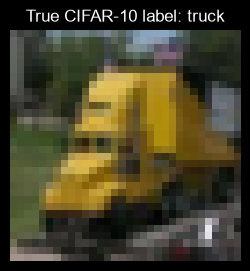

In [44]:
raw_sample_image, raw_target_index = raw_train_full[train_indices[0]]
raw_sample_label = raw_train_full.classes[raw_target_index]

# TODO: input_tensor = evaluation_transform(raw_sample_image).unsqueeze(0).to(DEVICE)
input_tensor = evaluation_transform(raw_sample_image).unsqueeze(0).to(DEVICE)
with torch.inference_mode():
    probabilities = pretrained_model(input_tensor).softmax(dim=1)[0]

top_probabilities, top_indices = probabilities.topk(5)

print("CIFAR-10 label:", raw_sample_label)
print("ImageNet model's top 5 guesses:")
for probability, class_index in zip(top_probabilities, top_indices):
    category = imagenet_categories[class_index.item()]
    print(f"  {category:25s} {probability.item():.1%}")

plt.figure(figsize=(3, 3))
plt.imshow(raw_sample_image)
plt.title(f"True CIFAR-10 label: {raw_sample_label}")
plt.axis("off")
plt.show()

<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q6.2:** هیچ‌کدام از ۱۰۰۰ category مربوط به ImageNet دقیقاً با نام‌های CIFAR-10 یعنی "automobile"، "ship"، "truck" یا "airplane" نوشته نشده‌اند. با این حال top-5 guess را بررسی کنید: آیا نشانه‌ای وجود دارد که model به‌جای حدس تصادفی، چیزی از نظر بصری *معقول* می‌بیند (مثلاً object مرتبط، shape مشابه یا material مشابه)؟ برای شواهد، نام یکی از top-5 categoryها را نقل کنید.

> **پاسخ گروه:**

شباهت بصری بین دو کلاس وجود دارد و پیشبینی ها رندوم نیست

moving van                36.9%

**Q6.3:** چرا این جمله اشتباه است که «این نتیجه ثابت می‌کند ResNet18 همین حالا مسئله 4-class ما را حل می‌کند»؟ قبل از اینکه model بتواند به *سؤال خود ما* پاسخ دهد، دقیقاً چه چیزی هنوز باید تغییر کند؟

> **پاسخ گروه:**

لایه فولی کانکتد آخر باید تغییر کند به این علت که با ساختار خروجی و لیبل های مسئله ما تطابق ندارد گویا مدل دیدن را بلد است اما به زبان مسئله ما نمی تواند تفسیر کند

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## Calibration bug

یک دماسنج با calibration اشتباه هنوز یک عدد نشان می‌دهد؛ فقط آن عدد با اطمینان *اشتباه* است. اینجا هم همین اتفاق می‌افتد: یک pretrained model تقریباً روی هر image tensor با shape مناسب اجرا می‌شود، حتی اگر preprocessing آن اشتباه باشد، و باز هم probabilityهایی ظاهراً مطمئن تولید می‌کند.

در ادامه code یکی از اعضای تیم برای اجرای یک تصویر با pretrained model آمده است. او اصرار دارد code درست است چون «crash نمی‌کند».

```python
# Teammate's code
image, _ = raw_train_full[5]

my_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

input_tensor = my_transform(image).unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    probs = pretrained_model(input_tensor).softmax(dim=1)[0]

print("Top guess:", imagenet_categories[probs.argmax().item()])
```

**Q6.4:** code بدون error اجرا می‌شود و یک category چاپ می‌کند. با این حال دقیقاً کدام line اشتباه است؟ با ارجاع به تشبیه "calibration" توضیح دهید چرا filterهای یک pretrained model انتظار range عددی مشخصی را دارند و این code آن range را فراهم نمی‌کند. مقدار صحیح mean/std که باید استفاده شود چیست؟ (این مقادیر را کمی قبل‌تر در همین Part print کرده‌اید.)

> **پاسخ گروه:**

در ترنسفورم آمار های مربوط به میانگین و واریانس غلط است و تصویر مطابق با انتظار مدل نیست

لیبل خروجی مدل رو با لیبل واقعی آن تصویر در CIFAR-10 مقایسه نمی کند

**Q6.5 (یک bug دوم و پنهان‌تر):** حتی بعد از اصلاح mean/std، اگر این هم‌گروهی بعداً برای **training** به `my_transform` augmentationهایی مثل `RandomHorizontalFlip` و `RandomCrop` اضافه کند اما همان transform را بدون تغییر برای **validation** هم استفاده کند، یک mismatch دیگر باقی می‌ماند. این اشتباه دقیقاً در کدام بخش/Session قبلی درس مطرح شده بود (نام Session یا concept را بگویید) و چرا استفاده مجدد از یک transform object برای training و evaluation، مستقل از اینکه mean/std چه مقداری هستند، مشکل ایجاد می‌کند؟

> **پاسخ گروه:**

برای ولیدیشن نباید ترنسفورم با آگمنتیشن زد و باید به صورت بیس لاین باشد.

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 7 — Freeze، Extract، Cache، Train (حدود ۳۵ دقیقه)

## Code review: pull request مربوط به "feature extraction" یک هم‌گروهی

یکی از اعضای تیم، بعد از Session 4، implementation زیر را برای Experiment C ارسال کرده است. پیام او این است: *"pretrained ResNet18 را load کردم، head را برای 4 class خودمان عوض کردم، train کردم و train accuracy عالی گرفتم. Merge کنیم؟"*

```python
feature_model = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features = feature_model.fc.in_features
feature_model.fc = nn.Linear(num_features, len(class_names))
feature_model = feature_model.to(DEVICE)

optimizer = torch.optim.Adam(feature_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    feature_model.train()
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = feature_model(images)
        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

**Q7.1 (حداقل سه مشکل جدا پیدا کنید):** گروه باید حداقل سه ایراد مستقل در این PR پیدا کند که هر کدام به یک concept مشخص از امروز یا Session 4 مربوط باشند. برای هر مورد مشخص کنید کدام line مسئول مشکل است و کدام concept را نقض می‌کند. برای شروع، یکی از جاهای مهم line مربوط به `optimizer` است: دقیق بررسی کنید `feature_model.parameters()` شامل چه parameterهایی است، در حالی که یک "fixed feature extractor" واقعی باید دقیقاً کدام parameterها را train کند.

> **پاسخ گروه (حداقل ۳ مورد):**
> 1.مشکل بسیار جدی این کد این است که BACKBon  فریز نشده است
>
> 2.مشکل بسیار جدی بعدی این است که requires_grad = False نکرده
>
> 3.همه پارامتر ها رو به اپتیمایزر داده در حالی که فقط لایه کلاسبندی رو باید میداده
>
> 4.مدل رو روی حالت eval و بخش کلاس بندی رو روی حالت train نذاشته

**Q7.2:** مشخصاً برای bug مربوط به training loop (نه مشکل optimizer)، کدام concept از Part 3 توضیح می‌دهد که چرا اجرای `feature_model.train()` روی *کل* model — و نه فقط head — مشکل‌ساز است، با اینکه `requires_grad=False` همچنان جلوی update شدن weightهای backbone را می‌گیرد؟

> **پاسخ گروه:**
چون آمار های استخراج شده توسط بچ نرمالایز تغییر میکند و این آمار با توجه به آمار های بچ های تصادفی دچار تغییر میشود
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## حالا نسخه اصلاح‌شده را بسازید

**TODO:** backbone را به‌درستی freeze کنید و head را طبق ترتیبی که Session 4 تأکید کرده بود جایگزین کنید: (۱) pretrained weights را load کنید، (۲) freeze کنید، (۳) classifier را جایگزین کنید.

</div>


In [48]:
weights = ResNet18_Weights.DEFAULT
feature_model = resnet18(weights=weights)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(feature_model.fc.parameters(), lr=0.001)
# TODO: همه parameterهای feature_model را freeze کنید (requires_grad = False)
for param in feature_model.parameters():
    param.requires_grad = False

num_features = feature_model.fc.in_features
for param in feature_model.fc.parameters():
    param.requires_grad = True
# TODO: feature_model.fc را با یک nn.Linear(num_features, len(class_names)) جدید جایگزین کنید
#       (یک layer تازه‌ساخته‌شده به‌صورت پیش‌فرض trainable است)
feature_model.fc = nn.Linear(num_features, len(class_names))
feature_model = feature_model.to(DEVICE)



total_parameters = sum(p.numel() for p in feature_model.parameters())
trainable_parameters = sum(p.numel() for p in feature_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters:    {total_parameters - trainable_parameters:,}")

Total parameters:     11,178,564
Trainable parameters: 2,052
Frozen parameters:    11,176,512


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q7.3:** با ۴ target class، انتظار دارید layer جدید `fc` چند trainable parameter داشته باشد؟ محاسبه را نشان دهید (weights + biases) و سپس بررسی کنید با عدد `trainable_parameters` که گروه کمی قبل print کرده یکسان است.

> **پاسخ گروه:**
>
اره

**TODO:** رفتار gradient را مستقیماً بررسی کنید؛ فقط به parameter count اعتماد نکنید.

</div>


In [50]:
# training/validation transformها را با ImageNet statistics بسازید
# (مطابق همان چیزی که در Part 6 برای bug بررسی کردید).
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset_aug = TransformSubset(raw_train_full, train_indices, train_transform, label_map=project_label_map)
train_loader = DataLoader(train_dataset_aug, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

# TODO: کل model را در eval mode قرار دهید، سپس فقط feature_model.fc را در train mode بگذارید
feature_model.eval()
feature_model.fc.train()
# TODO: یک forward pass اجرا کنید، loss را حساب کنید، feature_model.zero_grad() و سپس loss.backward() را صدا بزنید
out = feature_model(images)

loss = loss_fn(out,labels)

feature_model.zero_grad()

loss.backward()

optimizer.step()

print("Backbone conv1 requires_grad:", feature_model.conv1.weight.requires_grad)
print("Backbone conv1 .grad is None:", feature_model.conv1.weight.grad is None)
print("Head fc requires_grad:", feature_model.fc.weight.requires_grad)
print("Head fc .grad is None:", feature_model.fc.weight.grad is None)

Backbone conv1 requires_grad: False
Backbone conv1 .grad is None: True
Head fc requires_grad: True
Head fc .grad is None: False


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q7.4:** چهار نتیجه‌ای را که از cell بالا انتظار دارید، به همان ترتیبی که print می‌شوند بنویسید و تأیید کنید output واقعی گروه با هر چهار مورد یکسان است.

> **پاسخ گروه:**
یکسان است
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

## یک shortcut خلاقانه: آیا backbone باید در هر epoch اجرا شود؟

این سؤال مستقیماً در منابع امروز مطرح نشده است؛ بنابراین به‌صورت گروهی استدلال کنید.

**Q7.5 (نکته اصلی):** weightهای backbone در Experiment C هیچ‌وقت تغییر نمی‌کنند؛ چون frozen هستند. در هر epoch، code شبیه `run_epoch` دوباره هر training image را از *کل* backbone مربوط به ResNet18 عبور می‌دهد، فقط برای اینکه همان feature vector با 512 عدد را تولید کند که epoch قبلی هم تولید کرده بود (input image تغییر نکرده و backbone frozen هم تغییری نکرده است). اگر training set شما ۱۶۰ تصویر داشته باشد و ۱۰ epoch train کنید، loop ساده در مجموع چند **backbone forward pass** انجام می‌دهد؟ اگر output backbone برای هر تصویر بین epochها تغییر نمی‌کند، واقعاً چند forward pass *لازم* است؟

> **پاسخ گروه (هر دو عدد را نشان دهید):**
اگر تصاویر در ایپوک از لایه استخراج ویژگی فریز شده عبور کند 1600 فروارد پس داریم که بسیار سنگین است ولی میتوانیم چون خروجی تصاویر پس از عبور از این بخش مدل ایکسان است ، یکبار تمام تصاویر را به مدل نشان دهیم و سپس نتیجه را ذخیره کنیم و صرفا Head مدل نتایج ذخیره شده بک بن را فروارد پس کند و این کار به شدت محاسبات را کاهش میدهد
>
**TODO:** این ایده را به code تبدیل کنید. feature vector با 512 dimension مربوط به هر training و validation image را فقط **یک بار** extract کنید، سپس یک classifier کوچک را مستقیماً روی vectorهای cached train کنید؛ یعنی در epoch loop دیگر هیچ ResNet forward pass انجام نشود.

</div>


In [52]:
@torch.no_grad()
def extract_all_features(model, dataset, batch_size=16):
    '''Run every image in `dataset` through the frozen backbone exactly once,
    returning (features, labels) as plain tensors.'''
    backbone = nn.Sequential(*list(model.children())[:-1])  # everything except fc
    backbone.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    all_features, all_labels = [], []

    # TODO: برای هر batch شامل (images, labels) در `loader`:
    #         images را به DEVICE منتقل کنید
    #         آن‌ها را از `backbone` عبور دهید
    #         نتیجه را با torch.flatten(x, start_dim=1) به [batch, 512] تبدیل کنید
    #         featureهای flatten‌شده (منتقل‌شده به cpu) و labels را به listها اضافه کنید
    for image, label in loader:
        image = image.to(DEVICE)
        output = backbone(image)
        flatten_output = torch.flatten(output,1)
        all_features.append(flatten_output.cpu())
        all_labels.append(label.cpu())
    return torch.cat(all_features), torch.cat(all_labels)


train_features, train_labels = extract_all_features(feature_model, train_dataset_aug)
val_features, val_labels = extract_all_features(feature_model, val_dataset)

print("Cached train feature tensor shape:", train_features.shape)
print("Cached val feature tensor shape:  ", val_features.shape)

Cached train feature tensor shape: torch.Size([160, 512])
Cached val feature tensor shape:   torch.Size([80, 512])


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**TODO:** یک `nn.Linear(512, num_classes)` ساده را مستقیماً روی featureهای cached train کنید. این مرحله باید بسیار سریع باشد: نه image loading داریم، نه convolution، فقط یک matrix multiply کوچک در هر batch.

</div>


In [54]:
def train_on_cached_features(train_features, train_labels, val_features, val_labels,
                              num_classes, epochs=30, lr=1e-3, seed=SEED):
    torch.manual_seed(seed)
    head = nn.Linear(train_features.shape[1], num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(head.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_features = train_features.to(DEVICE)
    train_labels = train_labels.to(DEVICE)
    val_features = val_features.to(DEVICE)
    val_labels = val_labels.to(DEVICE)

    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
    start_time = time.perf_counter()

    for epoch in range(epochs):
        # TODO: head را در train mode قرار دهید، gradientها را zero کنید، train_features را از head عبور دهید،
        head.train()
        output = head(train_features)

        #       CrossEntropyLoss نسبت به train_labels را حساب کنید، backward و optimizer.step() را اجرا کنید
        # TODO: train accuracy این epoch را محاسبه کنید
        loss = loss_fn(output, train_labels)
        train_accuracy = (output.argmax(dim=1) == train_labels).float().mean().item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        head.eval()
        with torch.no_grad():
            val_logits = head(val_features)
            val_loss = loss_fn(val_logits, val_labels).item()
            val_accuracy = (val_logits.argmax(dim=1) == val_labels).float().mean().item()

        # TODO: مقدارهای train_loss / train_accuracy / val_loss / val_accuracy این epoch را به `history` اضافه کنید
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        print(f"Epoch {epoch + 1:02d}/{epochs} | val loss: {val_loss:.3f} | val acc: {val_accuracy:.1%}")

    elapsed_seconds = time.perf_counter() - start_time
    return head, history, elapsed_seconds


trained_head, cached_history, cached_time = train_on_cached_features(
    train_features, train_labels, val_features, val_labels, num_classes=len(class_names), epochs=30,
)
print(f"\nTotal training time on cached features: {cached_time:.2f} seconds")

Epoch 01/30 | val loss: 1.395 | val acc: 36.3%
Epoch 02/30 | val loss: 1.327 | val acc: 37.5%
Epoch 03/30 | val loss: 1.287 | val acc: 41.2%
Epoch 04/30 | val loss: 1.253 | val acc: 41.2%
Epoch 05/30 | val loss: 1.212 | val acc: 42.5%
Epoch 06/30 | val loss: 1.162 | val acc: 43.8%
Epoch 07/30 | val loss: 1.106 | val acc: 48.8%
Epoch 08/30 | val loss: 1.053 | val acc: 60.0%
Epoch 09/30 | val loss: 1.007 | val acc: 70.0%
Epoch 10/30 | val loss: 0.968 | val acc: 71.2%
Epoch 11/30 | val loss: 0.934 | val acc: 73.8%
Epoch 12/30 | val loss: 0.904 | val acc: 76.2%
Epoch 13/30 | val loss: 0.874 | val acc: 76.2%
Epoch 14/30 | val loss: 0.845 | val acc: 78.8%
Epoch 15/30 | val loss: 0.815 | val acc: 80.0%
Epoch 16/30 | val loss: 0.786 | val acc: 85.0%
Epoch 17/30 | val loss: 0.759 | val acc: 86.3%
Epoch 18/30 | val loss: 0.733 | val acc: 86.3%
Epoch 19/30 | val loss: 0.710 | val acc: 85.0%
Epoch 20/30 | val loss: 0.689 | val acc: 85.0%
Epoch 21/30 | val loss: 0.669 | val acc: 85.0%
Epoch 22/30 |

<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

**Q7.6:** این روش نسبت به چیزی که از نسخه ساده انتظار داشتید (یک ResNet18 forward pass کامل برای هر تصویر در هر epoch) چقدر زمان برد؟ لازم نیست برای جواب دادن نسخه ساده را واقعاً اجرا کنید؛ از اعداد Q7.5 و این واقعیت استفاده کنید که یک linear layer به‌مراتب ارزان‌تر از یک CNN forward pass کامل است.

> **پاسخ گروه:**
به جای اینکه در هر دور آموزش فیچر وکتوری که قرار نیست تغییر کند را وارد محاسبات کنیم که بسیار وقت گیر است ! صرفا یکبار خروجی را ذخیره کردم و سرعت پردازش به شکل چشم گیری بالا رفت
>
**Q7.7 (محدودیت واقعی caching):** این caching trick فقط به این دلیل کار می‌کند که backbone **frozen** است. فرض کنید در جلسه بعد بعضی layerهای backbone را unfreeze کنیم و هنگام training اجازه update شدن به آن‌ها بدهیم (`fine-tuning`). آیا featureهایی که قبل از شروع training cache شده‌اند، در epoch 5 مربوط به fine-tuning هنوز معتبر هستند؟ چرا یا چرا نه؟

> **پاسخ گروه:**

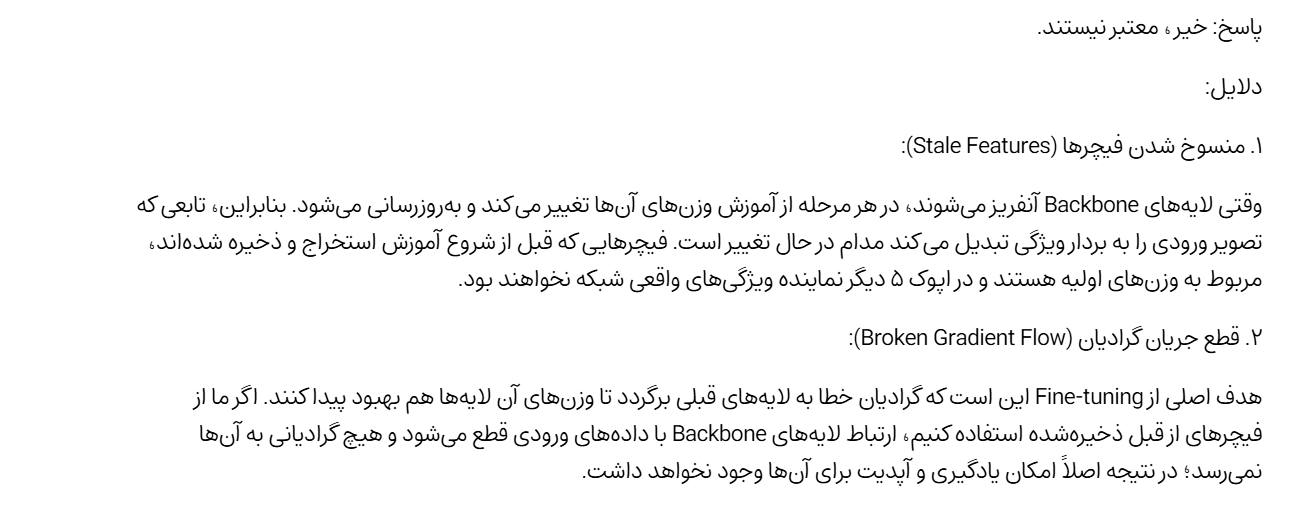

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 8 — Experiment Log: واقعاً چه چیزی نتیجه را تغییر داد؟ (حدود ۱۵ دقیقه)

**TODO:** با استفاده از `cached_history` مربوط به Part 7، سطر Experiment C گروه خودتان را کامل کنید.

</div>


In [55]:
best_epoch_index = int(np.argmin(cached_history["val_loss"]))

# TODO: شماره بهترین epoch یعنی (best_epoch_index + 1) و train_accuracy و val_accuracy
#       همان epoch را از cached_history چاپ کنید
print("Best epoch",best_epoch_index+1,"train accuracy: ",cached_history["train_accuracy"][best_epoch_index],"val accuracy: ",cached_history["val_accuracy"][best_epoch_index])

Best epoch 30 train accuracy:  0.96875 val accuracy:  0.9125000238418579


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

| Experiment | Model | Random augmentation | Initial weights | Trainable parameters |    Best validation accuracy | Notes |
|---|---|:---:|---|---:|----------------------------:|---|
| A | Small CNN | No | Random | All |                     *(73%)* | |
| B | Small CNN | Yes | Random | All |                     *(69%)* | |
| C | ResNet18 | Yes | ImageNet pretrained | Classifier only (`{trainable_parameters:,}`) | *(not enough time to run )* | |

**Q8.1:** سطر Experiment C در جدول بالا را با نتیجه‌های خودتان کامل کنید.

> **پاسخ گروه:**
> 91%

**Q8.2 (نکته مهم، مستقیماً از Session 4):** در Experiment C نسبت به A و B فقط یک چیز تغییر نکرد؛ architecture مدل، initial weights، اینکه کدام parameterها trainable هستند و همچنین input resolution (pipelineهای حدود `128×128` در برابر `224×224`) همگی هم‌زمان تغییر کردند. با این شرایط، آیا نتیجه Experiment C به‌تنهایی می‌تواند ثابت کند که مشخصاً *pretraining* — نه مثلاً فقط «architecture مربوط به ResNet18 از Small CNN مناسب‌تر است» — علت improvement مشاهده‌شده بوده است؟ حداقل experiment اضافه‌ای که قبلاً در Session 4 نام برده شد و می‌تواند اثر pretraining را isolate کند چیست؟

> **پاسخ گروه:**
> باید بین یه رز نت با وزن تصادفی و یه رزنت با وزن از پیش آموخته شده آزمایش کننیم تا معماری شبکه رول اوت بشه

**Q8.3 (prediction مبتنی بر مقاله، قبل از دیدن جواب):** اعداد Table 2 در Part 1 را به یاد بیاورید: رفتن از plain-18 به plain-34 نتیجه را *بدتر* کرد (error بیشتر شد)، اما رفتن از ResNet-18 به ResNet-34 نتیجه را *بهتر* کرد. حالا Experiment C خودتان را در نظر بگیرید. اگر یک ResNet18 با random weight و *بدون pretraining* به‌عنوان frozen feature extractor استفاده می‌شد — آن را Experiment C0 بنامید — انتظار دارید validation accuracy آن به Experiment C نزدیک‌تر باشد یا به Experiment A با Small CNN و random weight؟ پاسخ را با استفاده از تفاوت "architecture vs. learned weights" در thought experiment ابتدای Session 4 توجیه کنید، نه صرفاً با حدس.

> **پاسخ گروه:**
> اگر فریز کنیم دقت افتضاح میشه چون هیچی قرار نیست یادبگییره  و ویژگی های استخراج شده توسط لایه استخراج ویژگی کاملا تصادفی و غلطه

</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Part 9 — دادگاه Misconception (حدود ۱۰ دقیقه)

مدرس به گروه شما **یکی** از misconceptionهای زیر را اختصاص می‌دهد (اگر وقت بود می‌توانید خودتان انتخاب کنید). گروه ۵ دقیقه فرصت دارد یک verdict حدود ۳۰ ثانیه‌ای آماده کند: ابتدا misconception را بیان کنید، سپس آن را **با شواهد مشخص از تمرین امروز** اصلاح کنید؛ یعنی از یک عدد، output یک cell یا citation مقاله که امروز گروه تولید کرده استفاده کنید، نه فقط تکرار یک تعریف.

**فهرست پرونده‌ها:**

1. «ResNet مشکل `overfitting` را حل می‌کند.»
2. «مشکل `degradation` همان `vanishing gradients` است.»
3. «`shortcut` یادگیری را دور می‌زند و `residual branch` کار مهمی انجام نمی‌دهد.»
4. «در هر `residual block`، input همیشه بدون تغییر به output اضافه می‌شود.»
5. «یک network عمیق‌تر حتماً باید accuracy بیشتری از یک network کم‌عمق‌تر داشته باشد.»
6. «فقط با جایگزین کردن final layer، `backbone` به‌صورت خودکار freeze می‌شود.»
7. «وقتی parameterها frozen هستند، model دیگر هیچ computation انجام نمی‌دهد.»
8. «`eval()` و `requires_grad=False` قابل جایگزینی‌اند و دقیقاً یک کار انجام می‌دهند.»
9. «`pretrained model` قبلاً دقیقاً imageهای خود ما را دیده و به همین دلیل `transfer` کار می‌کند.»
10. «۵۱۲ feature استخراج‌شده همان ۵۱۲ output class با بیشترین احتمال هستند.»

**Q9.1:** شماره misconception اختصاص‌داده‌شده به گروه را بنویسید و متن verdict حدود ۳۰ ثانیه‌ای خود را در ۲ تا ۴ جمله آماده کنید. حتماً به یک مدرک مشخص از بخش‌های قبلی notebook ارجاع دهید؛ برای مثال «در Q1.2 محاسبه کردیم که...» یا «در Part 7 بررسی کردیم که...».

> **رأی گروه:**
8. به پارت 3 مراجعه کنید که صرفا .eval زدیم ولی با رد شدن داده های جدید از بچ آمار های مدل تغییر کرد
</div>


<div class="fa-rtl" dir="rtl" style="direction: rtl; text-align: right;">

---
# Stretch Goals (اختیاری، اگر گروه زودتر تمام کرد)

1. **Bottleneck block، به‌اختصار.** بخشی از مقاله را پیدا کنید که building block نوع "bottleneck" برای ResNet-50/101/152 معرفی می‌شود (نزدیک انتهای Section 4.1 / ابتدای بحث architectureهای عمیق‌تر). در هر block سه convolution وجود دارد: `1×1 → 3×3 → 1×1`. با استفاده از ستون 50-layer در Table 1 و این نکته که هر block سه conv دارد، محاسبه تعداد layer در Q4.2 را برای ResNet50 دوباره انجام دهید و تأیید کنید نتیجه 50 می‌شود.

2. **Confidence، نه فقط correctness.** برای ۱۰ validation image، predicted probability یا softmax confidence در model مربوط به pretrained feature extraction را برای predictionهای درست و غلط مقایسه کنید. آیا model معمولاً وقتی اشتباه می‌کند confidence کمتری دارد؟ یک prediction پیدا کنید که با confidence بالا *اشتباه* باشد؛ خود تصویر واقعاً چه چیزی را نشان می‌دهد؟

3. **یک Equation دیگر بخوانید.** بخشی از مقاله را پیدا کنید که gradient عبارت `y = x + F(x)` نسبت به `x` را بیان می‌کند (در Session 3 آن را به صورت `∂y/∂x = I + ∂F(x)/∂x` دیدید). مقاله یک caveat مهم درباره اینکه این رابطه چه چیزی را تضمین می‌کند و چه چیزی را تضمین نمی‌کند اضافه می‌کند. آن caveat را با بیان خودتان بازنویسی کنید و آن را به تعریف دقیق `degradation` در Q1.6 ربط دهید: residual connection یک *structural aid* برای optimization است، نه تضمینی برای پیدا کردن optimum.

---

# چک‌لیست تحویل

- [ ] Part 0: بحث اولیه موافق/مخالف ثبت شده است.
- [ ] Part 1: اعداد Table 2 نوشته شده‌اند؛ `degradation` و `overfitting` با شواهد Figure 4 از هم تفکیک شده‌اند؛ `is_degradation` پیاده‌سازی و تست شده است.
- [ ] Part 2: Eq. (1)/(2) نوشته و توضیح داده شده‌اند؛ `BasicResidualBlock.forward()` پیاده‌سازی شده؛ predictionهای shape با Figure 3 بررسی شده‌اند.
- [ ] Part 3: رفتار BatchNorm در train/eval با code بررسی شده، نه فقط توصیف.
- [ ] Part 4: blueprint مربوط به ResNet18 با Table 1 audit شده؛ shape trace کامل شده و با prediction دستی مقایسه شده است.
- [ ] Part 5: جدول Shape Detective 2.0 کامل و trap case مشخص شده است.
- [ ] Part 6: pretrained model load و query شده؛ calibration bug و bug مربوط به استفاده مشترک از val/train transform پیدا شده‌اند.
- [ ] Part 7: حداقل ۳ bug در PR اشتباه پیدا شده؛ freeze+head صحیح پیاده‌سازی و با gradient بررسی شده؛ feature caching پیاده‌سازی و زمان‌گیری شده است.
- [ ] Part 8: Experiment Log با اعداد خودتان کامل شده و درباره control مربوط به C0 استدلال شده است.
- [ ] Part 9: یک verdict درباره misconception با استناد به شواهد ارائه شده است.

خسته نباشید — گروه شما حالا یک پروژه را از «deep network با random weight که حتی ممکن است به‌خوبی train نشود» تا «استفاده مسئولانه از سال‌ها computation انجام‌شده توسط دیگران» پیش برده است؛ در کنار code خودتان، خود مقاله هم منبع دوم شواهد شما بوده است.

</div>
